In [61]:
import pandas as pd
import seaborn as sns

In [62]:
import numpy as np
import pandas as pd


In [63]:
import seaborn as sns

In [64]:
data=sns.load_dataset('titanic')
data.head(2)
data.info

<bound method DataFrame.info of      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_male deck  embark_town alive  alone  
0      man        True  NaN  Southampton    no  False  
1    woman       False    C    Cherbourg   yes  False  
2    woman       False  NaN  Southampton   yes   True  
3    woman       False    C  Southampton   yes  False  
4      man        True  NaN  Southampton    no   True  
..     ...         ...  ...          ...   ...    ...  
886    man        True  NaN  Southampton    no   True  
887  woman       False    B  Southampton   yes   True  
888  woman       False  NaN  Southampton    no  False  
889    man        True    C    Cherbourg   yes   True  
890    man        True  NaN   Queenstown    no   True  

[891 rows x 15 columns]>

In [65]:
df=data[['survived','pclass','sex','age','fare']]
df



,survived,pclass,sex,age,fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
888,0,3,female,NaN,23.4500
889,1,1,male,26.0,30.0000


#before performing the transoformation make sure it doenst have negative(for log transform ) and null values

In [66]:
df.isnull().sum()
df['age'].fillna(df['age'].mean(),inplace=True)

/tmp/ipykernel_2031/4219545421.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(),inplace=True)
/tmp/ipykernel_2031/4219545421.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age'].fillna(df['age'].mean(),inplace=True)


In [67]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
fare,0


In [68]:

df.info



df.describe

df['fare']=df['fare'].astype(int)

df['age']=df['age'].astype(int)
df.head()

/tmp/ipykernel_2031/4176995795.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fare']=df['fare'].astype(int)
/tmp/ipykernel_2031/4176995795.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age']=df['age'].astype(int)


,survived,pclass,sex,age,fare
0,0,3,male,22,7
1,1,1,female,38,71
2,1,3,female,26,7
3,1,1,female,35,53
4,0,3,male,35,8


In [90]:
df.head()
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['sex']=le.fit_transform(df['sex'])

/tmp/ipykernel_2031/2449970582.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex']=le.fit_transform(df['sex'])


In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt


In [92]:
#we shall split the data into train and test 1st

X_train,X_test,y_train,y_test=train_test_split(df.drop('survived',axis=1),df['survived'],test_size=0.2,random_state=42)

In [105]:
X_train.shape,X_test.shape,y_test.shape,y_train.shape

((712, 4), (179, 4), (179,), (712,))

In [94]:
import scipy.stats  as stats

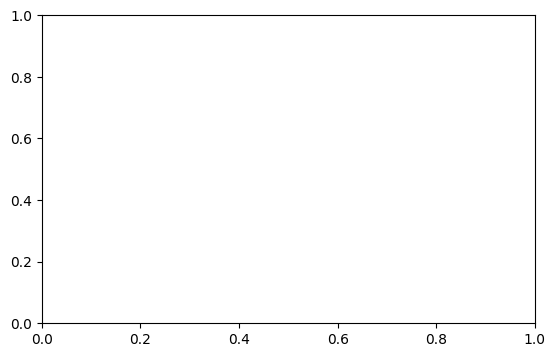

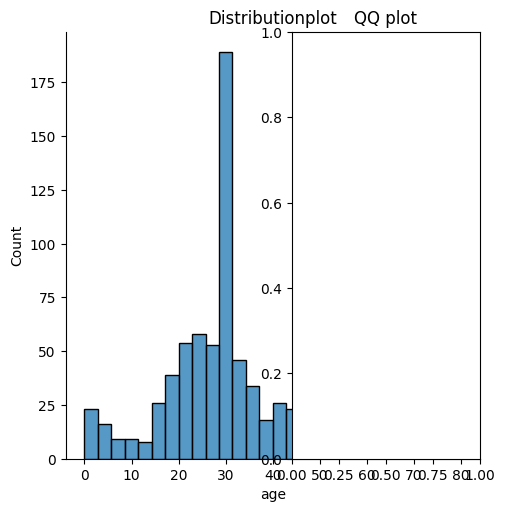

In [95]:
# #we shall see how the data is distributed using the ProbabiltyDisrtibution and QQ graph

# plt.figure(figsize=(14,4))
# plt.subplot(121)
# sns.displot(X_train['age'])
# plt.title("Distributionplot")

# plt.subplot(122)
# stats.probplot(X_train['age'],dist='norm')
# plt.title("QQ plot")
# plt.show()


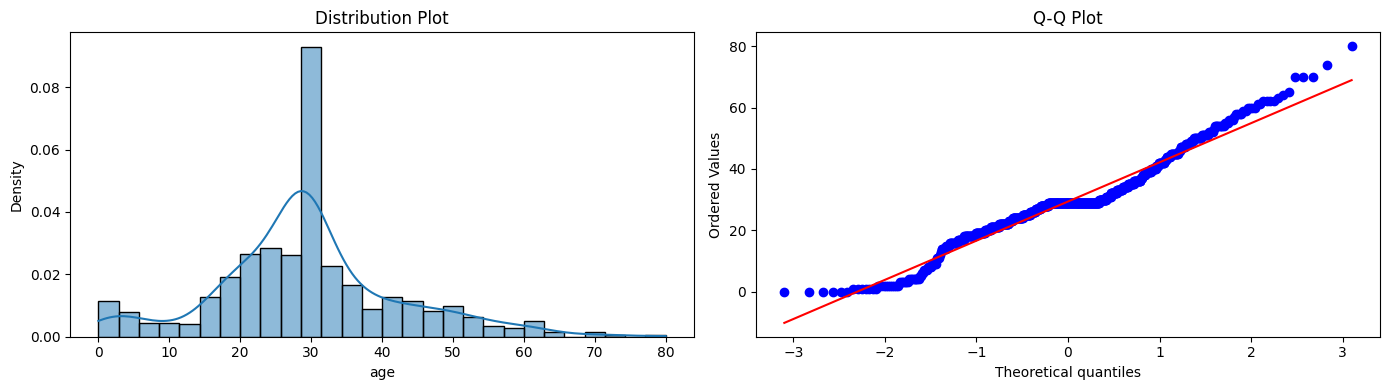

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Initialize the figure canvas (lowercase 'f')
plt.figure(figsize=(14, 4))

# 2. Left side: Probability Distribution Curve
plt.subplot(121)
sns.histplot(X_train['age'], kde=True, stat="density")  # histplot fits perfectly inside subplots
plt.title("Distribution Plot")

# 3. Right side: Q-Q Plot
plt.subplot(122)
stats.probplot(X_train['age'], dist="norm", plot=plt)  # added plot=plt to render it here
plt.title("Q-Q Plot")

# 4. Show the clean layout
plt.tight_layout()




plt.show()


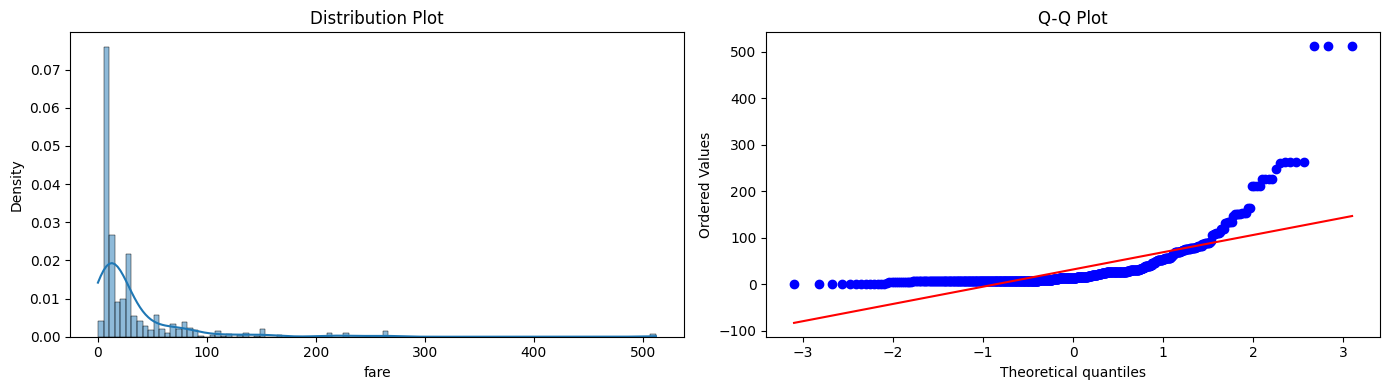

In [97]:
# 1. Initialize the figure canvas (lowercase 'f')
plt.figure(figsize=(14, 4))

# 2. Left side: Probability Distribution Curve
plt.subplot(121)
sns.histplot(X_train['fare'], kde=True, stat="density")  # histplot fits perfectly inside subplots
plt.title("Distribution Plot")

# 3. Right side: Q-Q Plot
plt.subplot(122)
stats.probplot(X_train['fare'], dist="norm", plot=plt)  # added plot=plt to render it here
plt.title("Q-Q Plot")

# 4. Show the clean layout
plt.tight_layout()




plt.show()

#here we can see that the fare is right skewed


In [98]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['sex']=le.fit_transform(df['sex'])

/tmp/ipykernel_2031/1589291012.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex']=le.fit_transform(df['sex'])


In [99]:
X_train['fare'].skew()

np.float64(4.874137196260257)

In [100]:
X_train

,pclass,sex,age,fare
331,1,1,45,28
733,2,1,23,13
382,3,1,32,7
704,3,1,26,7
813,3,0,6,31
...,...,...,...,...
106,3,0,21,7
270,1,1,29,31
860,3,1,41,14
435,1,0,14,120


In [101]:
trs=FunctionTransformer(func=np.log1p)

In [102]:
lr=LogisticRegression()
clf=DecisionTreeClassifier()

In [120]:
lr.fit(X_train,y_train)
clf.fit(X_train,y_train)



y_predlr=lr.predict(X_test)
y_predclf=clf.predict(X_test)


#se3ing the accuracy for the predictions

print(f"LogisticRegression{accuracy_score(y_test,y_predlr)}")
print(f"DesionTRee:{accuracy_score(y_test,y_predclf)}")

LogisticRegression0.7988826815642458
DesionTRee:0.7877094972067039


In [121]:
#Lets Transform the data
trs=FunctionTransformer(func=np.log1p)

In [160]:
X_trainTransformed=trs.fit_transform(X_train)

X_testTransformed=trs.fit_transform(X_test)

In [161]:
lr.fit(X_trainTransformed,y_train)
clf.fit(X_trainTransformed,y_train)



y_predlr=lr.predict(X_testTransformed)
y_predclf=clf.predict(X_testTransformed)


#se3ing the accuracy for the predictions

print(f"LogisticRegression{accuracy_score(y_test,y_predlr)}")
print(f"DesionTRee:{accuracy_score(y_test,y_predclf)}")

LogisticRegression0.7932960893854749
DesionTRee:0.7932960893854749


In [127]:
X_transformed = trs.fit_transform(X_train)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y_train,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y_train,scoring='accuracy',cv=10)))

LR 0.7963419405320814
DT 0.7963810641627543


Ploting the Differences (like age,fare before and after transformation)


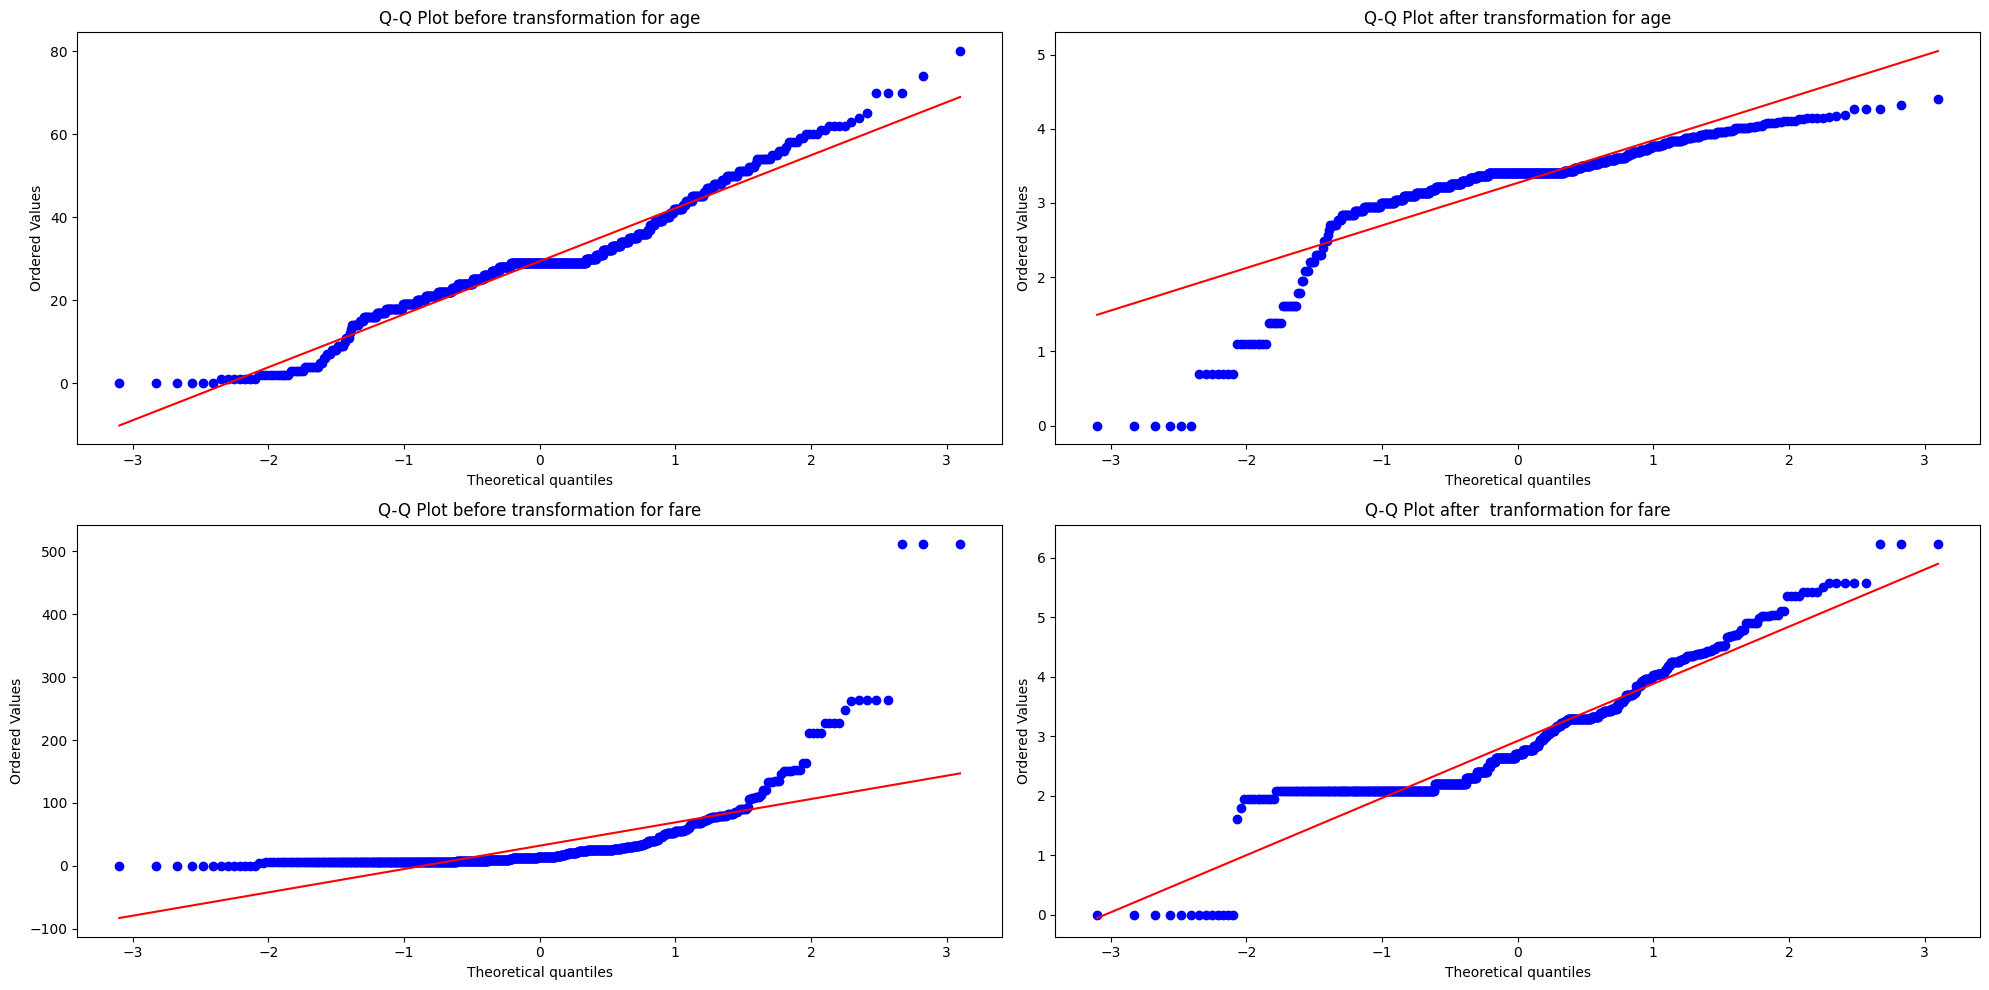

<Figure size 640x480 with 0 Axes>

In [140]:

plt.figure(figsize=(20, 10))

plt.subplot(2,2,1)
stats.probplot(X_train['age'], dist="norm", plot=plt)  # added plot=plt to render it here
plt.title("Q-Q Plot before transformation for age")


# 3. Right side: Q-Q Plot
plt.subplot(2,2,2)
stats.probplot(X_trainTransformed['age'], dist="norm", plot=plt)  # added plot=plt to render it here
plt.title("Q-Q Plot after transformation for age")


#FARE GRAPH
plt.subplot(2,2,3)
stats.probplot(X_train['fare'], dist="norm", plot=plt)  # added plot=plt to render it here
plt.title("Q-Q Plot before transformation for fare")


# 3. Right side: Q-Q Plot
plt.subplot(2,2,4)
stats.probplot(X_trainTransformed['fare'], dist="norm", plot=plt)  # added plot=plt to render it here
plt.title("Q-Q Plot after  tranformation for fare")

# 4. Show the clean layout
plt.tight_layout()

plt.show()


Lets Create a Funtion that takes the FuntionalTransformor as the parameter and then perform the operation (transformtion ) on the data and gives you the accuracy after performing with the trandofromed data


df.head()

In [141]:
df.head()

,survived,pclass,sex,age,fare
0,0,3,1,22,7
1,1,1,0,38,71
2,1,3,0,26,7
3,1,1,0,35,53
4,0,3,1,35,8


In [170]:
df

,survived,pclass,sex,age,fare
0,0,3,1,22,7
1,1,1,0,38,71
2,1,3,0,26,7
3,1,1,0,35,53
4,0,3,1,35,8
...,...,...,...,...,...
886,0,2,1,27,13
887,1,1,0,19,30
888,0,3,0,29,23
889,1,1,1,26,30


In [175]:
def performTransform(transform):
  X=df.iloc[:,1:5]
  y=df.iloc[:,0:1]


  trs = ColumnTransformer([('log',FunctionTransformer(transform),['fare'])],remainder='passthrough')


  X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
  lr=LogisticRegression()
  clf=DecisionTreeClassifier()


  lr.fit(X_train,y_train)
  clf.fit(X_train,y_train)



  y_predlr=lr.predict(X_test)
  y_predclf=clf.predict(X_test)


  print(f"LogisticRegression{accuracy_score(y_test,y_predlr)}")
  print(f"DesionTRee:{accuracy_score(y_test,y_predclf)}")


  X_trainTransformed=trs.fit_transform(X_train)

  X_testTransformed=trs.transform(X_test)

  lr.fit(X_trainTransformed,y_train)
  clf.fit(X_trainTransformed,y_train)



  y_predlr=lr.predict(X_testTransformed)
  y_predclf=clf.predict(X_testTransformed)


  #se3ing the accuracy for the predictions after transforimg

  print(f"LogisticRegression{accuracy_score(y_test,y_predlr)}")
  print(f"DesionTRee:{accuracy_score(y_test,y_predclf)}")


  plt.figure(figsize=(14, 4))
  plt.subplot(121)
  stats.probplot(X_train['fare'], dist="norm", plot=plt)  # added plot=plt to render it here
  plt.title("Q-Q Plot before transformation for fare")


  # 3. Right side: Q-Q Plot
  plt.subplot(122)
  stats.probplot(X_trainTransformed[:, 0], dist="norm", plot=plt)  # added plot=plt to render it here
  plt.title("Q-Q Plot after  tranformation for fare")

  # 4. Show the clean layout
  plt.tight_layout()

  plt.show()






/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression0.7988826815642458
DesionTRee:0.770949720670391
LogisticRegression0.7988826815642458
DesionTRee:0.7821229050279329


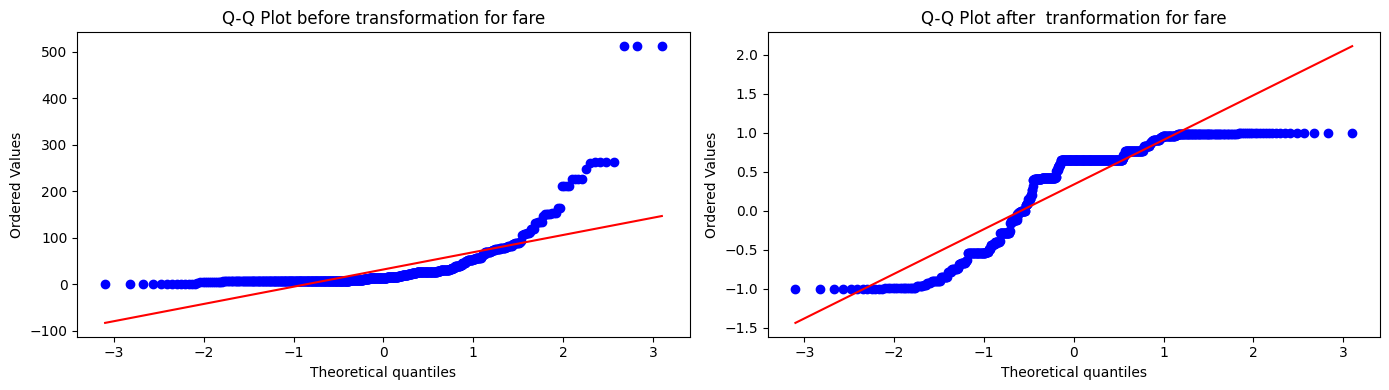

In [176]:
performTransform(np.sin)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression0.7988826815642458
DesionTRee:0.770949720670391
LogisticRegression0.8044692737430168
DesionTRee:0.770949720670391


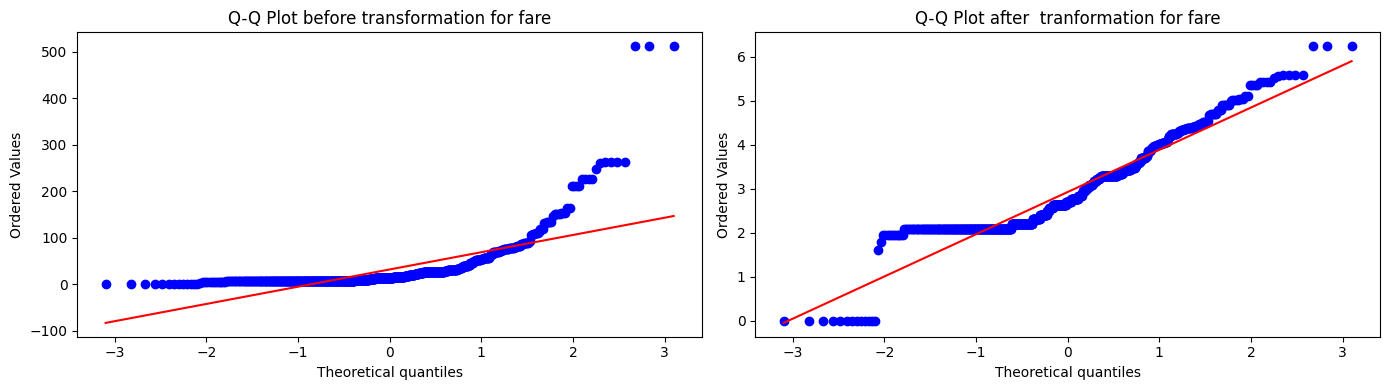

In [179]:
# 1. Log transformation
performTransform(np.log1p)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression0.7988826815642458
DesionTRee:0.770949720670391
LogisticRegression0.8044692737430168
DesionTRee:0.7821229050279329


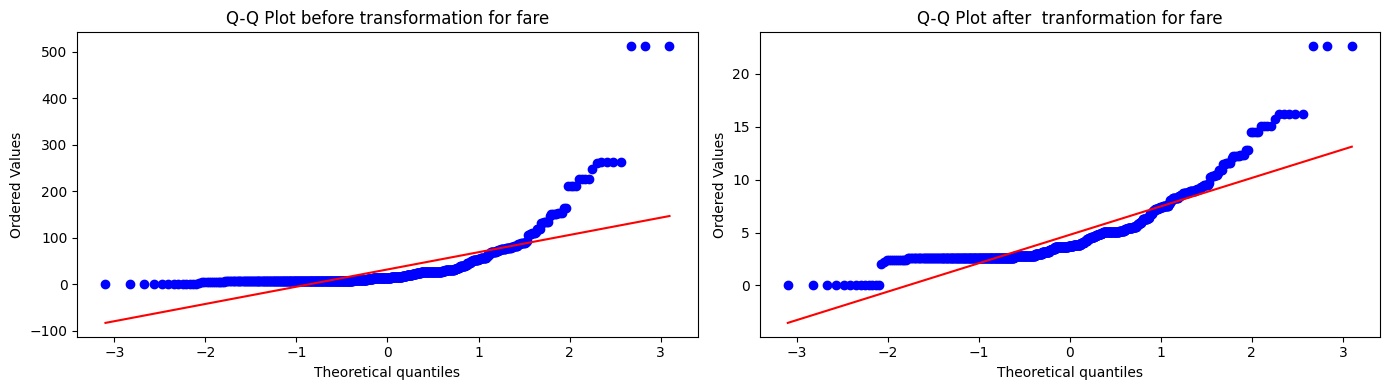

In [180]:
# 2. Square-root transformation

# Useful for reducing moderate right skew.

performTransform(np.sqrt)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression0.7988826815642458
DesionTRee:0.7821229050279329
LogisticRegression0.8044692737430168
DesionTRee:0.776536312849162


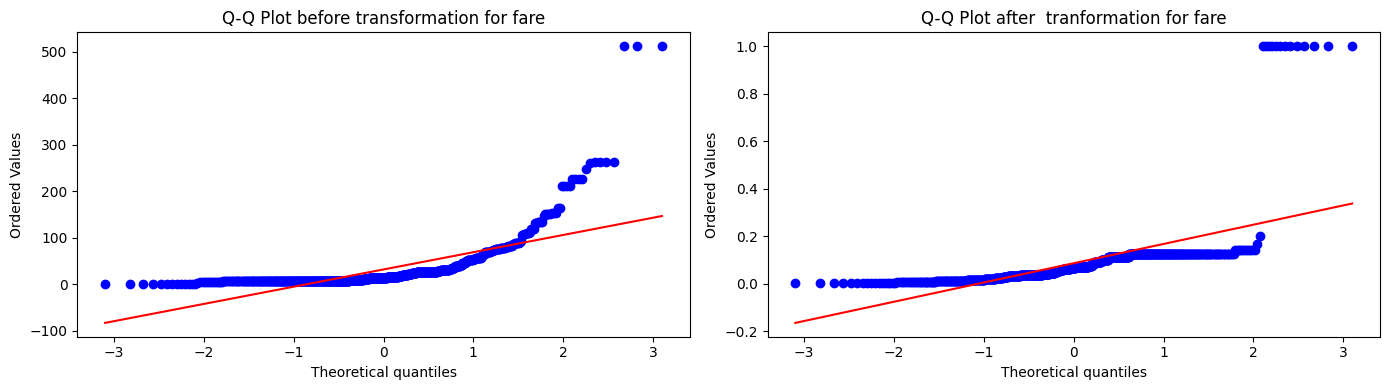

In [181]:
# 3. Reciprocal transformation

# Can strongly reduce the effect of large values.

performTransform(lambda x: 1 / (x + 1))

In [ ]:
# 4. Square transformation

# Can be useful when you want to emphasize larger values.

performTransform(lambda x: x ** 2)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression0.7988826815642458
DesionTRee:0.7821229050279329
LogisticRegression0.8044692737430168
DesionTRee:0.7541899441340782


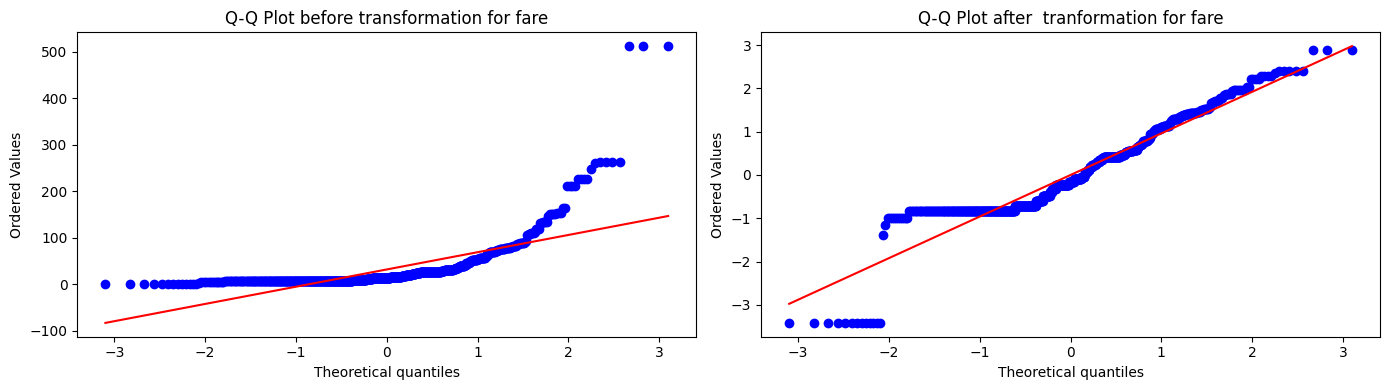

In [182]:
# Yeo-Johnson transformation

from sklearn.preprocessing import PowerTransformer

performTransform(
    lambda x: PowerTransformer(method='yeo-johnson').fit_transform(x)
)